# Document Layout Classification — EDA & Preprocessing

This notebook explores the document image dataset prior to modelling.

**Dataset:** 165 scanned document images across 3 classes — email, resume, and scientific publication.

**Steps:**
1. Dataset overview and class distribution
2. Image size and property analysis
3. Pixel intensity and brightness analysis
4. Key findings to inform modelling decisions

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('All imports successful')

All imports successful


In [2]:
# Define data directory and classes
DATA_DIR = '../data'
CLASSES = ['email', 'resume', 'scientific_publication']

# Count images per class
class_counts = {cls: len(os.listdir(os.path.join(DATA_DIR, cls))) for cls in CLASSES}

print('Dataset summary:')
for cls, count in class_counts.items():
    print(f'  {cls}: {count} images')
print(f'\nTotal images: {sum(class_counts.values())}')

Dataset summary:
  email: 55 images
  resume: 55 images
  scientific_publication: 55 images

Total images: 165


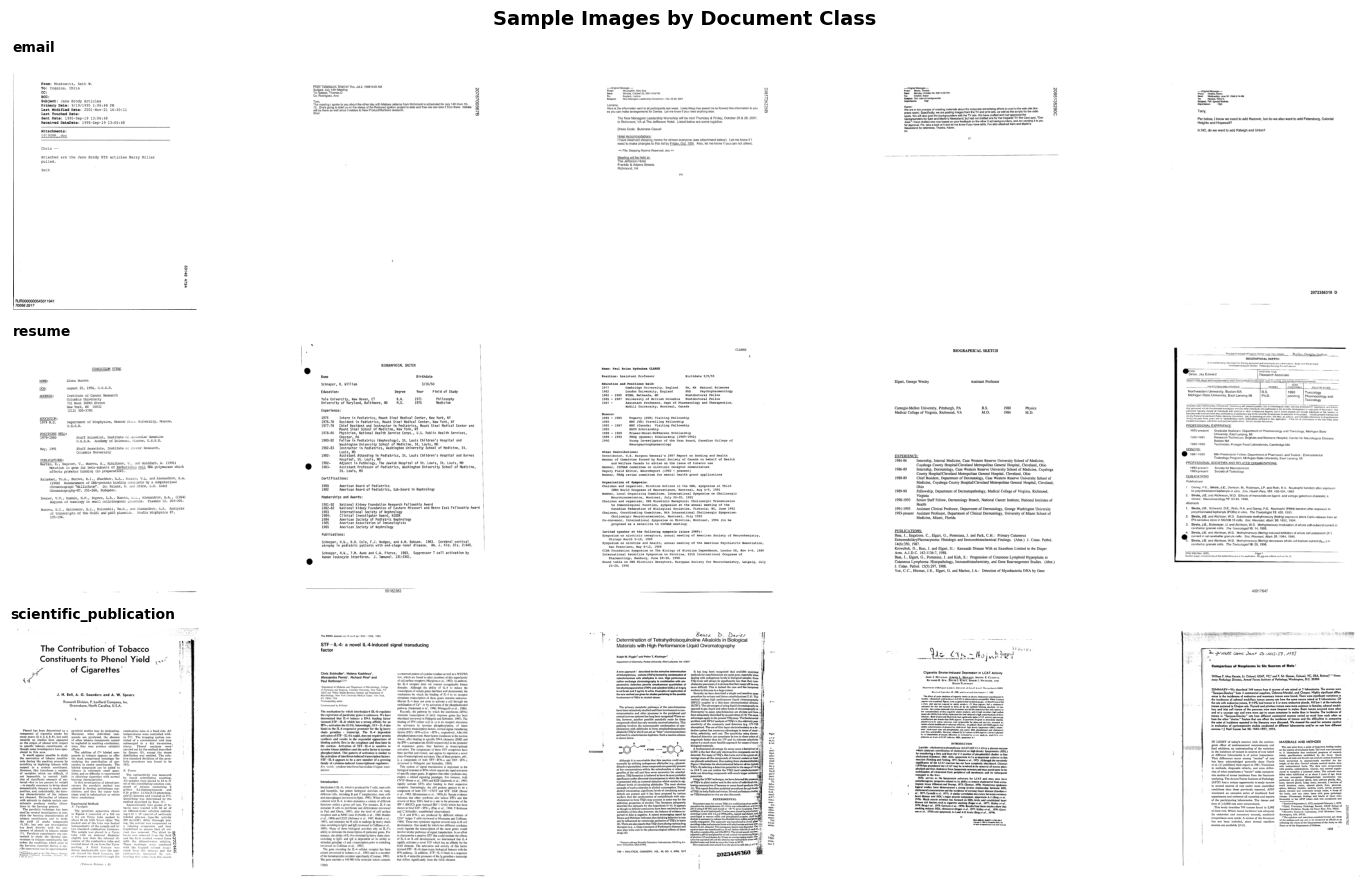

In [3]:
# Display sample images from each class
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for row, cls in enumerate(CLASSES):
    cls_dir = os.path.join(DATA_DIR, cls)
    images = os.listdir(cls_dir)[:5]
    for col, img_name in enumerate(images):
        img = Image.open(os.path.join(cls_dir, img_name)).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=10, fontweight='bold', loc='left')

plt.suptitle('Sample Images by Document Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# Analyse image sizes and properties
records = []

for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_dir):
        img = Image.open(os.path.join(cls_dir, img_name))
        width, height = img.size
        records.append({
            'class': cls,
            'filename': img_name,
            'width': width,
            'height': height,
            'aspect_ratio': round(width / height, 2),
            'mode': img.mode
        })

df = pd.DataFrame(records)
print(df.groupby('class')[['width', 'height', 'aspect_ratio']].describe().round(2))

                       width                                             \
                       count    mean    std    min    25%    50%    75%   
class                                                                     
email                   55.0  755.75   9.07  754.0  754.0  754.0  754.0   
resume                  55.0  756.56   7.96  754.0  754.0  754.0  754.0   
scientific_publication  55.0  766.13  16.94  754.0  754.0  754.0  776.5   

                              height          ...                  \
                          max  count    mean  ...     75%     max   
class                                         ...                   
email                   802.0   55.0  1000.0  ...  1000.0  1000.0   
resume                  801.0   55.0  1000.0  ...  1000.0  1000.0   
scientific_publication  855.0   55.0  1000.0  ...  1000.0  1000.0   

                       aspect_ratio                                            
                              count  mean   std   min 

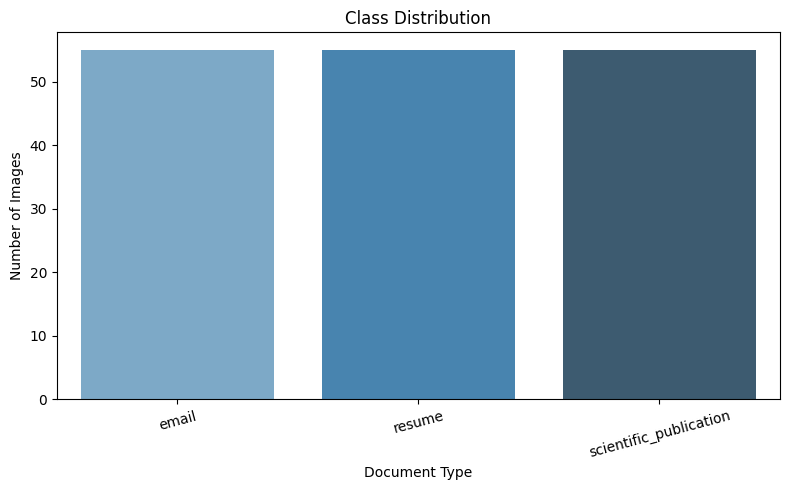

In [5]:
# Plot class distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='Blues_d')
plt.title('Class Distribution')
plt.xlabel('Document Type')
plt.ylabel('Number of Images')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

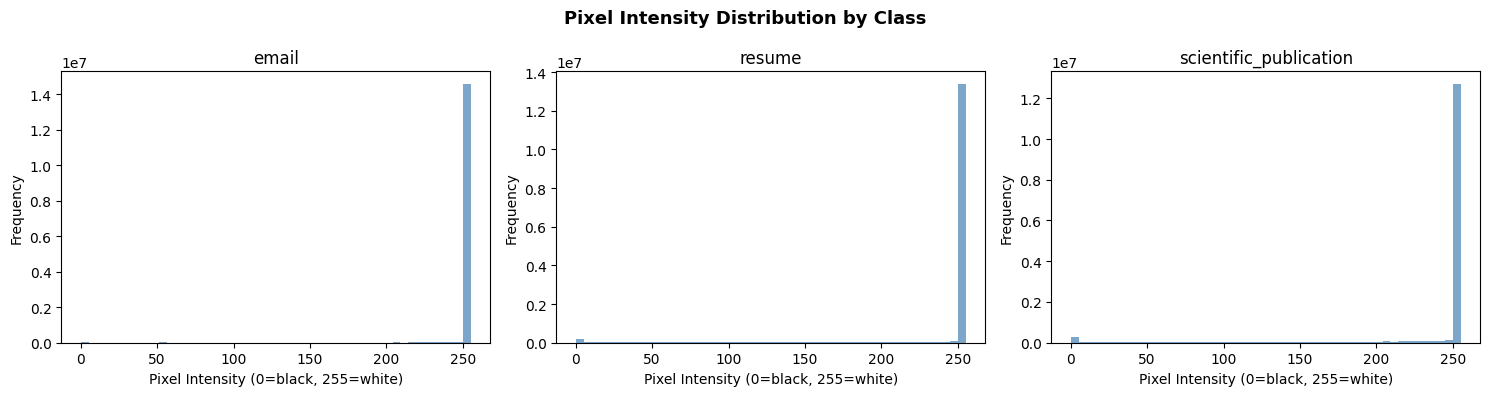

In [6]:
# Analyse pixel intensity distributions per class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cls in zip(axes, CLASSES):
    cls_dir = os.path.join(DATA_DIR, cls)
    pixel_values = []
    for img_name in os.listdir(cls_dir)[:20]:  # Sample 20 images per class
        img = Image.open(os.path.join(cls_dir, img_name)).convert('L')  # Convert to grayscale
        pixel_values.extend(np.array(img).flatten().tolist())
    
    ax.hist(pixel_values, bins=50, color='steelblue', alpha=0.7)
    ax.set_title(f'{cls}')
    ax.set_xlabel('Pixel Intensity (0=black, 255=white)')
    ax.set_ylabel('Frequency')

plt.suptitle('Pixel Intensity Distribution by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

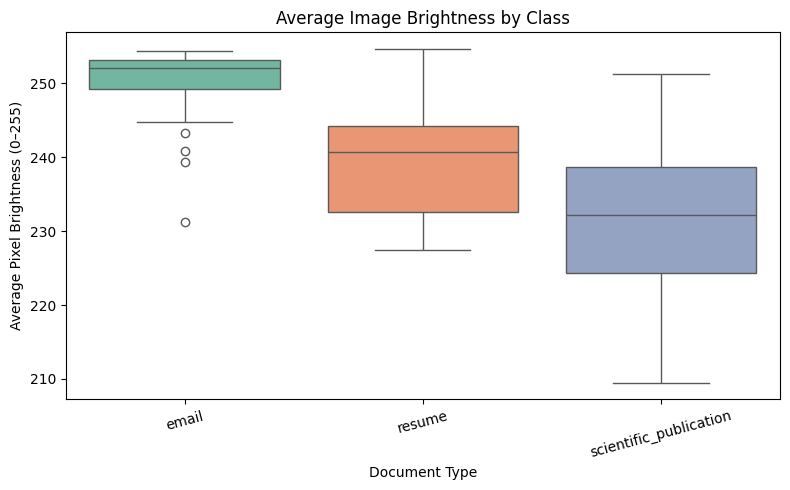

                        count    mean    std     min     25%     50%     75%  \
class                                                                          
email                    55.0  250.53   4.31  231.23  249.28  252.10  253.15   
resume                   55.0  238.87   6.91  227.46  232.65  240.70  244.28   
scientific_publication   55.0  231.27  10.03  209.49  224.40  232.18  238.70   

                           max  
class                           
email                   254.36  
resume                  254.66  
scientific_publication  251.22  


In [7]:
# Average brightness per class
brightness_data = []

for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_dir):
        img = Image.open(os.path.join(cls_dir, img_name)).convert('L')
        avg_brightness = np.array(img).mean()
        brightness_data.append({'class': cls, 'avg_brightness': avg_brightness})

brightness_df = pd.DataFrame(brightness_data)

plt.figure(figsize=(8, 5))
sns.boxplot(x='class', y='avg_brightness', data=brightness_df, palette='Set2')
plt.title('Average Image Brightness by Class')
plt.xlabel('Document Type')
plt.ylabel('Average Pixel Brightness (0–255)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(brightness_df.groupby('class')['avg_brightness'].describe().round(2))

## Key Findings

- **Balanced dataset:** 55 images per class — no class imbalance to handle
- **Consistent image sizes:** ~754×1000 pixels across all classes — minimal preprocessing needed
- **Portrait orientation:** Aspect ratio ~0.75 — images will be resized to 224×224 for the CNN
- **Visually distinct classes:** Clear brightness differences between classes (email > resume > scientific publication), suggesting the CNN should be able to learn meaningful visual features
- **Normalisation:** Standard ImageNet normalisation values (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) will be applied during training